# Geometry across five Chilean fits

Measure how much the learned geometry changes across initialization seeds. Figure S9 separates agreement in participant distances, proposal distances, and ordering along the first principal component (PC1).

**Inputs:** the five two-dimensional fits in `outputs/models/Chile_dim2_seed*`, included and regenerated by notebooks 02 and 04. **Outputs:** `outputs/figures/FigS9.pdf`, correlation matrices and ranges in `outputs/tables`, and sample and numerical-check tables in `outputs/diagnostics`.

**Run or explore:** run top to bottom in a fresh kernel. This notebook does not refit models. It recomputes distances for every distinct pair of participants and is more demanding than the other plotting notebooks. `BLOCK_SIZE` controls temporary memory, not the statistical result.

All five fits use the same participants, proposals, and held-out partition. Computation uses float64 Euclidean distances. No pair sampling or rounded distance cache is used. Arbitrary PC1 signs are removed when measuring ordering agreement.


Change `SEEDS` to compare any two or more available two-dimensional Chilean fits. All selected fits must contain the same participants and proposals in the same row order. Matrix sizes are derived from the selection.

In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png")


## Setup

The inputs are the five two-dimensional coordinate fits from notebooks 02 and 04. S0–S4 correspond to initialization seeds 101, 201, 301, 401 and 501. The code below records that mapping explicitly.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from scipy.linalg import svd
from sklearn.utils.extmath import svd_flip
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "data/raw").is_dir(), "Open from the project root or notebooks directory."

DATA = ROOT / "outputs/models"
SEEDS = [101, 201, 301, 401, 501]
TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"
DIAGNOSTICS = ROOT / "outputs" / "diagnostics"
for directory in [TABLES, FIGURES, DIAGNOSTICS]:
    directory.mkdir(parents=True, exist_ok=True)
N_FITS = len(SEEDS)
assert N_FITS >= 2 and len(set(SEEDS)) == N_FITS
FIT_IDS = [f"S{i}" for i in range(N_FITS)]
BLOCK_SIZE = 1024
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "pdf.fonttype": 42,
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


## Read inputs and verify correspondence

Every fit must contain the same participants and proposals in the same order. Distance arrays are sorted by identifier. Principal-component calculations use the verified corresponding participant rows. The coordinates are used directly, without fit-specific reflections.

In [3]:
frames = {}
distance_coordinates = {}
input_records = []
for entity, key in [("proposals", "option_id"), ("participants", "uuid")]:
    frames[entity] = []
    distance_coordinates[entity] = []
    reference_ids = None
    for fit in FIT_IDS:
        seed = SEEDS[FIT_IDS.index(fit)]
        filename = "coordsP.csv" if entity == "proposals" else "coordsU.csv"
        path = DATA / f"Chile_dim2_seed{seed}" / filename
        frame = pd.read_csv(path).rename(columns={"id": "option_id"})
        assert list(frame.columns) == [key, "z1", "z2"]
        assert len(frame) >= 3
        assert frame[key].notna().all() and frame[key].is_unique
        identifiers = frame[key].to_numpy()
        if reference_ids is None:
            reference_ids = identifiers.copy()
        assert np.array_equal(identifiers, reference_ids), f"Row order differs: {entity}, {fit}"
        coordinates = frame[["z1", "z2"]].to_numpy(dtype=np.float64)
        assert np.isfinite(coordinates).all()
        assert ((coordinates >= 0) & (coordinates <= 1)).all()
        frames[entity].append(frame)
        distance_coordinates[entity].append(coordinates[np.argsort(identifiers)])
        input_records.append(
            {
                "entity": entity,
                "fit": fit,
                "seed": seed,
                "rows": len(frame),
                "unique_ids": frame[key].nunique(),
            }
        )
input_table = pd.DataFrame(input_records)
display(input_table)
input_table.to_csv(DIAGNOSTICS / "geometry_inputs.csv", index=False)
input_table.to_latex(DIAGNOSTICS / "geometry_inputs.tex", index=False, escape=True)


,entity,fit,seed,rows,unique_ids
0,proposals,S0,101,90,90
1,proposals,S1,201,90,90
2,proposals,S2,301,90,90
3,proposals,S3,401,90,90
4,proposals,S4,501,90,90
5,participants,S0,101,47574,47574
6,participants,S1,201,47574,47574
7,participants,S2,301,47574,47574
8,participants,S3,401,47574,47574
9,participants,S4,501,47574,47574


## Pearson correlations of distances without dense matrices

For every unordered pair of distinct entities, the code computes Euclidean distance in each fit using float64. Off-diagonal blocks include every pair and diagonal blocks include only their strict upper triangle.

The accumulator stores the pair count, sums and cross-products. These recover the Pearson correlation of the complete distance vectors. The function contains the full calculation and performs no file I/O. Block size controls temporary memory only.

In [4]:
def distance_correlations_in_blocks(coordinate_arrays, block_size):
    """Pearson correlations over all distinct entity pairs, in float64."""
    n_fits = len(coordinate_arrays)
    n_entities = len(coordinate_arrays[0])
    assert block_size > 0
    assert all(z.shape == (n_entities, 2) for z in coordinate_arrays)
    pair_count = 0
    sums = np.zeros(n_fits, dtype=np.float64)
    cross_products = np.zeros((n_fits, n_fits), dtype=np.float64)
    largest_block_pairs = 0
    for row_start in range(0, n_entities, block_size):
        row_stop = min(row_start + block_size, n_entities)
        for col_start in range(row_start, n_entities, block_size):
            col_stop = min(col_start + block_size, n_entities)
            diagonal_block = row_start == col_start
            if diagonal_block:
                keep = np.triu_indices(row_stop - row_start, k=1)
                block_pairs = len(keep[0])
            else:
                block_pairs = (row_stop - row_start) * (col_stop - col_start)
            if block_pairs == 0:
                continue
            values = np.empty((n_fits, block_pairs), dtype=np.float64)
            for fit_index, coordinates in enumerate(coordinate_arrays):
                distances = cdist(
                    coordinates[row_start:row_stop],
                    coordinates[col_start:col_stop],
                    metric="euclidean",
                )
                values[fit_index] = distances[keep] if diagonal_block else distances.ravel()
            sums += values.sum(axis=1)
            cross_products += values @ values.T
            pair_count += block_pairs
            largest_block_pairs = max(largest_block_pairs, block_pairs)
    assert pair_count == n_entities * (n_entities - 1) // 2
    # Sum[(x - mean(x)) * (y - mean(y))] = sum(x*y) - sum(x)*sum(y)/N.
    # This gives exact full-vector covariance terms without storing those vectors.
    centered_products = cross_products - np.outer(sums, sums) / pair_count
    variance_terms = np.diag(centered_products)
    assert np.all(variance_terms > 0)
    correlations = centered_products / np.sqrt(np.outer(variance_terms, variance_terms))
    correlations = np.clip(correlations, -1, 1)
    np.fill_diagonal(correlations, 1.0)
    return correlations, pair_count, largest_block_pairs


## Check the block calculation against dense distances

A small dense calculation provides an independent check of diagonal, off-diagonal and final partial blocks. Both calculations use float64 Euclidean distances. Only this verification uses a subset. The figure uses every distinct pair.

In [5]:
n_participants = len(distance_coordinates["participants"][0])
sample_indices = np.linspace(0, n_participants - 1, min(23, n_participants), dtype=int)
small_coordinates = [z[sample_indices] for z in distance_coordinates["participants"]]
dense_vectors = [cdist(z, z)[np.triu_indices(len(z), k=1)] for z in small_coordinates]
dense_correlation = np.corrcoef(dense_vectors)
check_records = []
for block_size in [1, 7, 23, 32]:
    block_correlation, pair_count, largest_block = distance_correlations_in_blocks(
        small_coordinates, block_size
    )
    max_error = float(np.max(np.abs(block_correlation - dense_correlation)))
    assert np.allclose(block_correlation, dense_correlation, atol=1e-12, rtol=0)
    check_records.append(
        {
            "block_size": block_size,
            "entities": len(sample_indices),
            "pairs": pair_count,
            "maximum_absolute_error": max_error,
            "tolerance": 1e-12,
            "passed": True,
        }
    )
equivalence_table = pd.DataFrame(check_records)
display(equivalence_table)
equivalence_table.to_csv(DIAGNOSTICS / "geometry_block_equivalence.csv", index=False)
equivalence_table.to_latex(DIAGNOSTICS / "geometry_block_equivalence.tex", index=False)


,block_size,entities,pairs,maximum_absolute_error,tolerance,passed
0,1,23,253,2.220446e-15,1.000000e-12,True
1,7,23,253,1.443290e-15,1.000000e-12,True
2,23,23,253,1.998401e-15,1.000000e-12,True
3,32,23,253,1.998401e-15,1.000000e-12,True


## Calculate all proposal and participant distance correlations

The following cell evaluates all distinct pairs among 90 proposals and 47,574 participants for each fit. It records the exact number of pairs, excludes the diagonal and does not duplicate symmetric pairs. No full participant-by-participant matrix is allocated.

In [6]:
distance_matrices = {}
calculation_records = []
for entity in ["proposals", "participants"]:
    matrix, pair_count, largest_block = distance_correlations_in_blocks(
        distance_coordinates[entity], BLOCK_SIZE
    )
    assert np.isfinite(matrix).all() and np.allclose(matrix, matrix.T)
    distance_matrices[entity] = matrix
    calculation_records.append(
        {
            "entity": entity,
            "entities": len(distance_coordinates[entity][0]),
            "fits": len(FIT_IDS),
            "unordered_pairs_per_fit": pair_count,
            "block_size": BLOCK_SIZE,
            "largest_block_pairs": largest_block,
        }
    )
    matrix_table = pd.DataFrame(matrix, index=FIT_IDS, columns=FIT_IDS)
    matrix_table.index.name = "fit"
    display(matrix_table)
    matrix_table.to_csv(TABLES / f"geometry_{entity}_pearson.csv")
    matrix_table.to_latex(TABLES / f"geometry_{entity}_pearson.tex", float_format="%.6f")
calculation_table = pd.DataFrame(calculation_records)
display(calculation_table)
calculation_table.to_csv(DIAGNOSTICS / "geometry_calculation.csv", index=False)
calculation_table.to_latex(DIAGNOSTICS / "geometry_calculation.tex", index=False)


,S0,S1,S2,S3,S4
fit,,,,,
S0,1.000000,0.563516,0.629081,0.501280,0.616391
S1,0.563516,1.000000,0.549180,0.501133,0.538047
S2,0.629081,0.549180,1.000000,0.531071,0.572368
S3,0.501280,0.501133,0.531071,1.000000,0.551854
S4,0.616391,0.538047,0.572368,0.551854,1.000000


,S0,S1,S2,S3,S4
fit,,,,,
S0,1.000000,0.646123,0.689794,0.613523,0.623379
S1,0.646123,1.000000,0.654317,0.579881,0.604695
S2,0.689794,0.654317,1.000000,0.648406,0.646620
S3,0.613523,0.579881,0.648406,1.000000,0.642294
S4,0.623379,0.604695,0.646620,0.642294,1.000000


,entity,entities,fits,unordered_pairs_per_fit,block_size,largest_block_pairs
0,proposals,90,5,4005,1024,4005
1,participants,47574,5,1131618951,1024,1048576


## First-component ordering across fits

The code centers the coordinates (z2, z1), computes their full singular-value decomposition and retains PC1. For the saved signed diagnostic, `svd_flip(u_based_decision=True)` makes the score with greatest absolute magnitude positive. No ideological labels determine orientation.

Ordering stability uses absolute Spearman correlations because reversing PC1 preserves the same ordering up to orientation. The signed matrix is also saved. Absolute correlations do not correct for changes in which direction is the dominant component, or establish stability of the full two-dimensional map.

In [7]:
pca_scores = []
pca_records = []
for fit_index, fit in enumerate(FIT_IDS):
    coordinates = frames["participants"][fit_index][["z1", "z2"]].to_numpy(dtype=np.float64)
    coordinates = coordinates[:, [1, 0]]
    centered = coordinates - coordinates.mean(axis=0)
    U, singular_values, Vt = svd(centered, full_matrices=False)
    U, Vt = svd_flip(U, Vt, u_based_decision=True)
    scores = U[:, 0] * singular_values[0]
    assert scores[np.argmax(np.abs(scores))] > 0
    pca_scores.append(scores)
    pca_records.append(
        {
            "fit": fit,
            "participants": len(scores),
            "loading_z2": Vt[0, 0],
            "loading_z1": Vt[0, 1],
            "explained_variance_ratio": singular_values[0] ** 2 / np.sum(singular_values**2),
            "sign_anchor_row_zero_based": int(np.argmax(np.abs(scores))),
        }
    )
pca_correlation = spearmanr(np.column_stack(pca_scores), axis=0).statistic
# SciPy returns a scalar for two columns rather than a 2 × 2 matrix.
if N_FITS == 2:
    pca_correlation = np.array([[1.0, pca_correlation], [pca_correlation, 1.0]])
assert pca_correlation.shape == (N_FITS, N_FITS) and np.isfinite(pca_correlation).all()
pca_table = pd.DataFrame(pca_correlation, index=FIT_IDS, columns=FIT_IDS)
pca_table.index.name = "fit"
display(pca_table)
pca_table.to_csv(TABLES / "geometry_pca_spearman.csv")
pca_table.to_latex(TABLES / "geometry_pca_spearman.tex", float_format="%.6f")
# Axis direction is arbitrary. Compare ordering up to a reflection of PC1.
# Keep the signed correlations above for inspection. Distance correlations
# retain their sign because negative distance agreement is not a reflection.
pca_absolute_correlation = np.abs(pca_correlation)
pca_absolute_table = pd.DataFrame(pca_absolute_correlation, index=FIT_IDS, columns=FIT_IDS)
pca_absolute_table.index.name = "fit"
display(pca_absolute_table)
pca_absolute_table.to_csv(TABLES / "geometry_pca_absolute_spearman.csv")
pca_absolute_table.to_latex(TABLES / "geometry_pca_absolute_spearman.tex", float_format="%.6f")

pca_diagnostics = pd.DataFrame(pca_records)
display(pca_diagnostics)
pca_diagnostics.to_csv(DIAGNOSTICS / "geometry_pca.csv", index=False)
pca_diagnostics.to_latex(DIAGNOSTICS / "geometry_pca.tex", index=False, float_format="%.8f")


,S0,S1,S2,S3,S4
fit,,,,,
S0,1.000000,0.893824,0.903411,0.890400,0.889518
S1,0.893824,1.000000,0.912056,0.880589,0.883393
S2,0.903411,0.912056,1.000000,0.897328,0.891696
S3,0.890400,0.880589,0.897328,1.000000,0.888001
S4,0.889518,0.883393,0.891696,0.888001,1.000000


,S0,S1,S2,S3,S4
fit,,,,,
S0,1.000000,0.893824,0.903411,0.890400,0.889518
S1,0.893824,1.000000,0.912056,0.880589,0.883393
S2,0.903411,0.912056,1.000000,0.897328,0.891696
S3,0.890400,0.880589,0.897328,1.000000,0.888001
S4,0.889518,0.883393,0.891696,0.888001,1.000000


,fit,participants,loading_z2,loading_z1,explained_variance_ratio,sign_anchor_row_zero_based
0,S0,47574,-0.836894,0.547365,0.702972,12545
1,S1,47574,-0.974146,-0.225919,0.758525,12952
2,S2,47574,0.820555,-0.571567,0.715677,2475
3,S3,47574,-0.895579,-0.444903,0.672189,12799
4,S4,47574,0.997990,0.063366,0.658604,3447


## Correlation ranges and Figure S9

The table summarizes the ten correlations between distinct fits. Panels A and B show signed Pearson correlations of proposal and participant distances on scales from minus one to one. Panel C shows absolute Spearman correlations of participant PC1 scores on a scale from zero to one. Every displayed cell contains its value.

In [8]:
matrices = [
    distance_matrices["proposals"],
    distance_matrices["participants"],
    pca_absolute_correlation,
]
measures = [
    "Proposal distances: Pearson",
    "Participant distances: Pearson",
    "First component: absolute Spearman",
]
summary_records = []
for measure, matrix in zip(measures, matrices):
    correlations = matrix[np.triu_indices(len(FIT_IDS), k=1)]
    summary_records.append(
        {
            "measure": measure,
            "fit_pairs": len(correlations),
            "minimum": correlations.min(),
            "maximum": correlations.max(),
        }
    )
summary_table = pd.DataFrame(summary_records)
display(summary_table)
summary_table.to_csv(TABLES / "geometry_summary.csv", index=False)
summary_table.to_latex(TABLES / "geometry_summary.tex", index=False, float_format="%.6f")


,measure,fit_pairs,minimum,maximum
0,Proposal distances: Pearson,10,0.501133,0.629081
1,Participant distances: Pearson,10,0.579881,0.689794
2,First component: absolute Spearman,10,0.880589,0.912056


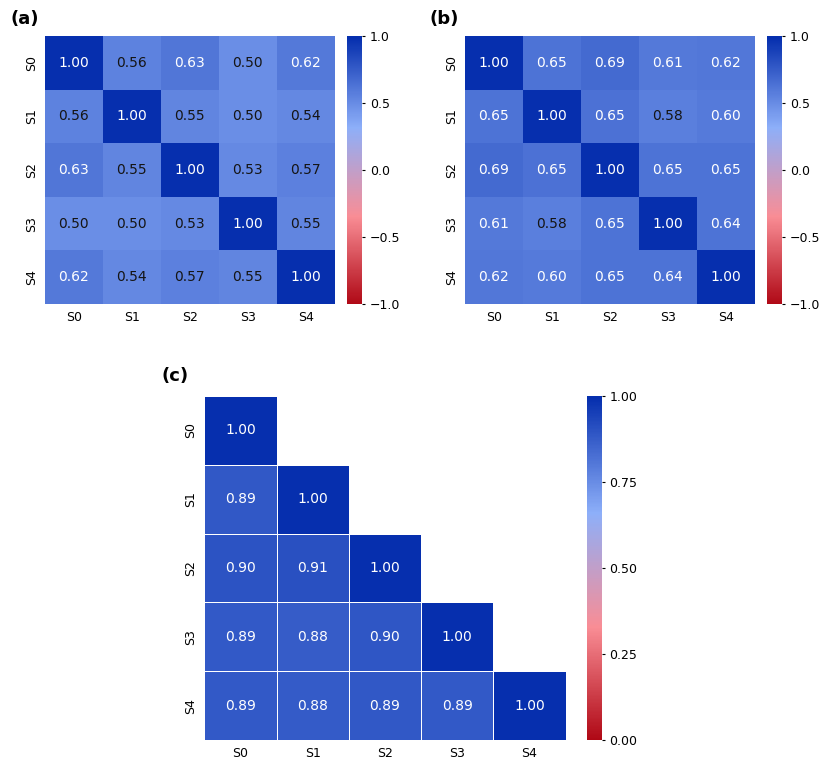

In [9]:
colors = ["#ae0613", "#f98d95", "#8daff9", "#062fae"]
cmap = LinearSegmentedColormap.from_list("geometry_correlation", colors)
fig = plt.figure(figsize=(8.4, 8.0), facecolor="white")
placements = [
    (0.065, 0.60, 0.345, 0.335),
    (0.565, 0.60, 0.345, 0.335),
    (0.255, 0.055, 0.43, 0.43),
]
colorbar_placements = [
    (0.425, 0.60, 0.018, 0.335),
    (0.925, 0.60, 0.018, 0.335),
    (0.71, 0.055, 0.018, 0.43),
]
for panel, matrix, placement, colorbar_placement in zip(
    "abc", matrices, placements, colorbar_placements
):
    ax = fig.add_axes(placement)
    mask = (
        np.triu(np.ones((N_FITS, N_FITS), dtype=bool), k=1)
        if panel == "c"
        else np.zeros((N_FITS, N_FITS), dtype=bool)
    )
    plotted = np.ma.array(matrix, mask=mask)
    mesh = ax.pcolormesh(
        np.arange(N_FITS + 1),
        np.arange(N_FITS + 1),
        plotted,
        cmap=cmap,
        vmin=0 if panel == "c" else -1,
        vmax=1,
        shading="flat",
        edgecolors="white" if panel == "c" else "none",
        linewidth=0.5,
    )
    ax.set(xlim=(0, N_FITS), ylim=(N_FITS, 0))
    labels = FIT_IDS
    ax.set_xticks(np.arange(N_FITS) + 0.5, labels, rotation=0)
    ax.set_yticks(np.arange(N_FITS) + 0.5, labels, rotation=90, va="center")
    ax.tick_params(axis="both", length=0, labelsize=9, pad=5)
    for spine in ax.spines.values():
        spine.set_visible(False)
    for row in range(N_FITS):
        for col in range(N_FITS):
            if not mask[row, col]:
                value = matrix[row, col]
                rgb = mesh.cmap(mesh.norm(value))[:3]
                luminance = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color="white" if luminance < 0.48 else "#151515",
                )
    cax = fig.add_axes(colorbar_placement)
    colorbar = fig.colorbar(
        mesh, cax=cax, ticks=[0, 0.25, 0.5, 0.75, 1] if panel == "c" else [-1, -0.5, 0, 0.5, 1]
    )
    colorbar.solids.set_rasterized(False)
    colorbar.solids.set_edgecolor("face")
    colorbar.ax.tick_params(labelsize=9, length=2)
    colorbar.outline.set_visible(False)
    ax.text(-0.12, 1.045, f"({panel})", transform=ax.transAxes, fontsize=13, fontweight="bold")
display(fig)
fig.savefig(FIGURES / "FigS9.pdf", format="pdf", bbox_inches="tight", pad_inches=0.06)
plt.close(fig)
